# Compare stacked masses to CosmoDC2 truth & CLCosmo_Sim

Takes the `CLClusterMass` output (`cluster_masses.pkl`) and compares our fitted
stacked WL masses against:

1. the **true** CosmoDC2 halo mass, from the matched-pairs catalogue
   (`matched_pairs_Mfofcut.fits`), and
2. the WL masses measured by **CLCosmo_Sim**.

Data access mirrors the CLCosmo_Sim notebooks: matched pairs via
`fits.open(...)[1].data` using the `cat1_*` (observed) / `cat2_*` (true halo)
columns, and CLCosmo_Sim masses via `np.load(..., allow_pickle=True)['masses']`.

Self-contained — run top to bottom. Every section prints the column names it
found and skips gracefully if a file is missing.

In [1]:
%matplotlib inline
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

# --- our fitted masses ------------------------------------------------------
MASSES_PKL = Path("./outputs/cluster_masses.pkl")            # output of CLClusterMass

# --- CosmoDC2 matched pairs (observed cluster <-> true halo) -----------------
MATCHED_PAIRS_FITS = Path(
    "/sps/lsst/users/ebarroso/CLPipeline/examples/"
    "cosmodc2_redmapper/ingest/matched_pairs_Mfofcut.fits"
)
COL_TRUE_Z    = "cat1_ztrue_cg"   # observed-cluster true redshift (cat1_*)
COL_RICHNESS  = "cat1_richness"   # observed richness (lambda)
COL_TRUE_MASS = "cat2_M200c"      # matched true-halo M200c [Msun] (cat2_*)
#   ^ swap COL_TRUE_Z for an observed-z column if you prefer to bin truth by
#     the same z variable your pipeline used.

# --- CLCosmo_Sim measured WL masses (optional) ------------------------------
CLCOSMOSIM = Path("/sps/lsst/users/ebarroso/CLCosmo_Sim")
CLCOSMOSIM_MASS_FILE = (
    CLCOSMOSIM / "cluster_mass_measurement"
    / "cluster-masses_1-halo=nfw+c-M=None_rmin=1.0-rmax=3.5_photoz=Truez.pkl"
)
# CLCosmo_Sim table columns (from their notebooks)
CLC_Z, CLC_OBS = "z_mean", "obs_mean"
CLC_LOGM, CLC_LOGM_ERR = "log10M200c_WL", "err_log10M200c_WL"

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
LIMS = [13.8, 15.1]   # log10 M axis range for the y=x panels

## Our fitted masses + bin edges

In [2]:
with open(MASSES_PKL, "rb") as fh:
    masses = pickle.load(fh)


def parse_edges(edges):
    # best-effort (z_lo, z_hi, r_lo, r_hi) from the upstream bin-edge attrs
    def pick(*names):
        for n in names:
            if n in edges:
                return float(np.ravel(edges[n])[0])
        return None
    z_lo = pick("z_min", "zmin", "redshift_min", "z_low")
    z_hi = pick("z_max", "zmax", "redshift_max", "z_high")
    r_lo = pick("richness_min", "rich_min", "lambda_min", "richness_low", "rich_low")
    r_hi = pick("richness_max", "rich_max", "lambda_max", "richness_high", "rich_high")
    return z_lo, z_hi, r_lo, r_hi


bins = []
for key, entry in masses.items():
    ens = entry.get("ensemble")
    if not ens:
        continue
    z_lo, z_hi, r_lo, r_hi = parse_edges(entry.get("cluster_bin_edges") or {})
    bins.append(dict(
        key=str(key), logm=ens["logm"], logm_err=ens["logm_err"],
        z_eff=entry.get("z_eff"), n_cl=entry.get("n_cl"),
        z_lo=z_lo, z_hi=z_hi, r_lo=r_lo, r_hi=r_hi,
        z_mid=None if z_lo is None else 0.5 * (z_lo + z_hi),
        r_mid=None if r_lo is None else 0.5 * (r_lo + r_hi),
    ))

print(f"{len(bins)} fitted bins")
if any(b["z_lo"] is None or b["r_lo"] is None for b in bins):
    print("WARNING: some bins have unparsed z/richness edges - extend parse_edges().")
    seen = sorted({k for e in masses.values() for k in (e.get("cluster_bin_edges") or {})})
    print("edge keys seen:", seen)

# group bins by redshift slice (used for colouring throughout)
zgroups = defaultdict(list)
for b in bins:
    zgroups[(b["z_lo"], b["z_hi"])].append(b)
zkeys = sorted(zgroups, key=lambda zk: (zk[0] if zk[0] is not None else 0))
zcolor = {zk: f"C{i}" for i, zk in enumerate(zkeys)}


def zlabel(zk):
    return f"{zk[0]:.2f} < z < {zk[1]:.2f}" if zk[0] is not None else "all z" 

24 fitted bins


## Matched pairs: true DC2 mass per bin

For each of our bins we select matched pairs inside the same
$(z,\lambda)$ box and take the mean true mass, following the CLCosmo_Sim
convention: mean of the *linear* masses, then $\log_{10}$; error is
$\mathrm{std}(\log_{10}M)/\sqrt{N}$.

In [3]:
have_truth = MATCHED_PAIRS_FITS.exists()
if not have_truth:
    print(f"matched-pairs file not found:\n  {MATCHED_PAIRS_FITS}")
else:
    with fits.open(MATCHED_PAIRS_FITS) as hdul:
        mp = hdul[1].data
        available = list(mp.columns.names)
        z_true = np.array(mp[COL_TRUE_Z], dtype=float)
        richness = np.array(mp[COL_RICHNESS], dtype=float)
        mass_true = np.array(mp[COL_TRUE_MASS], dtype=float)

    print(f"{len(z_true)} matched pairs")
    missing = [c for c in (COL_TRUE_Z, COL_RICHNESS, COL_TRUE_MASS) if c not in available]
    if missing:
        print("MISSING columns:", missing)
        print("available columns:", available)
        have_truth = False


def true_mass_in_bin(b):
    if None in (b["z_lo"], b["z_hi"], b["r_lo"], b["r_hi"]):
        return np.nan, np.nan, 0
    sel = ((z_true > b["z_lo"]) & (z_true < b["z_hi"]) &
           (richness > b["r_lo"]) & (richness < b["r_hi"]))
    n = int(sel.sum())
    if n == 0:
        return np.nan, np.nan, 0
    logm = np.log10(np.mean(mass_true[sel]))
    logm_err = np.std(np.log10(mass_true[sel])) / np.sqrt(n)
    return logm, logm_err, n


if have_truth:
    for b in bins:
        b["logm_true"], b["logm_true_err"], b["n_true"] = true_mass_in_bin(b)
    n_ok = sum(np.isfinite(b["logm_true"]) for b in bins)
    print(f"true mass computed for {n_ok}/{len(bins)} bins")

42754 matched pairs
true mass computed for 23/24 bins


## Plot 1 — our stacked WL mass vs true DC2 halo mass

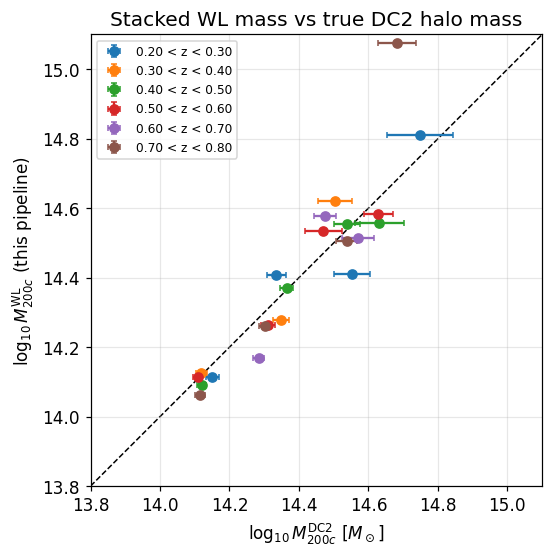

In [4]:
if have_truth:
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.plot(LIMS, LIMS, "--k", zorder=0, lw=1)
    for zk in zkeys:
        grp = [b for b in zgroups[zk] if np.isfinite(b.get("logm_true", np.nan))]
        if not grp:
            continue
        ax.errorbar(
            [b["logm_true"] for b in grp], [b["logm"] for b in grp],
            xerr=[b["logm_true_err"] for b in grp],
            yerr=[b["logm_err"] for b in grp],
            fmt="o", color=zcolor[zk], capsize=2, label=zlabel(zk),
        )
    ax.set_xlim(LIMS)
    ax.set_ylim(LIMS)
    ax.set_box_aspect(1)
    ax.set_xlabel(r"$\log_{10} M_{200c}^{\rm DC2}\ [M_\odot]$")
    ax.set_ylabel(r"$\log_{10} M_{200c}^{\rm WL}$ (this pipeline)")
    ax.set_title("Stacked WL mass vs true DC2 halo mass")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
else:
    print("Truth comparison skipped (matched-pairs file/columns unavailable).")

## CLCosmo_Sim WL masses

In [5]:
def load_clcosmosim_masses(path):
    path = Path(path)
    if not path.exists():
        return None
    # CLCosmo_Sim saves an npz-like archive (np.load(...)['masses']) despite
    # the .pkl extension; fall back to plain pickle just in case.
    try:
        return Table(np.load(path, allow_pickle=True)["masses"])
    except Exception:
        with open(path, "rb") as fh:
            obj = pickle.load(fh)
        return Table(obj["masses"] if isinstance(obj, dict) and "masses" in obj else obj)


clc = load_clcosmosim_masses(CLCOSMOSIM_MASS_FILE)
if clc is None:
    print(f"CLCosmo_Sim mass file not found:\n  {CLCOSMOSIM_MASS_FILE}")
    d = CLCOSMOSIM / "cluster_mass_measurement"
    if d.exists():
        print("\navailable files in", d, ":")
        for p in sorted(d.glob("cluster-masses_*")):
            print("  ", p.name)
else:
    print("CLCosmo_Sim columns:", clc.colnames)
    print(f"{len(clc)} bins")

CLCosmo_Sim columns: ['mask', 'chi2ndof', 'log10M200c_WL', 'err_log10M200c_WL', 'c_w', 'c_w_err', '1h_term', '2h_term', 'radius_model', 'chain', 'z_mean', 'obs_mean', 'obs_rms', 'radius', 'DSt', 'DSx', 'gt_individual', 'radius_individual', 'n_stack', 'cluster_id', 'z_individual', 'obs_individual', 'z_bin', 'obs_bin', 'Om1_W_l', 'richness', 'z']
28 bins


## Plot 2 — our stacked WL mass vs CLCosmo_Sim WL mass

Bins are matched by $(z,\lambda)$-box membership between the two pipelines
(their `z_mean`/`obs_mean` inside our bin edges), so identical binning is not
required.

24 bins matched to CLCosmo_Sim


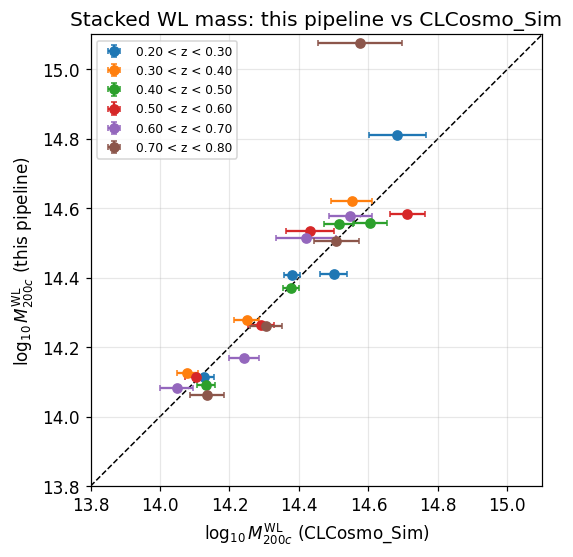

In [6]:
if clc is not None:
    zc = np.array(clc[CLC_Z], dtype=float)
    rc = np.array(clc[CLC_OBS], dtype=float)
    mc = np.array(clc[CLC_LOGM], dtype=float)
    mce = np.array(clc[CLC_LOGM_ERR], dtype=float)

    matched = []
    for b in bins:
        if None in (b["z_lo"], b["z_hi"], b["r_lo"], b["r_hi"]):
            continue
        sel = ((zc > b["z_lo"]) & (zc < b["z_hi"]) &
               (rc > b["r_lo"]) & (rc < b["r_hi"]))
        if sel.sum() == 0:
            continue
        matched.append(dict(
            ours=b["logm"], ours_err=b["logm_err"],
            theirs=float(np.mean(mc[sel])), theirs_err=float(np.mean(mce[sel])),
            zk=(b["z_lo"], b["z_hi"]),
        ))
    print(f"{len(matched)} bins matched to CLCosmo_Sim")

    if matched:
        fig, ax = plt.subplots(figsize=(5.2, 5.2))
        ax.plot(LIMS, LIMS, "--k", zorder=0, lw=1)
        g2 = defaultdict(list)
        for mm in matched:
            g2[mm["zk"]].append(mm)
        for zk in sorted(g2, key=lambda z: (z[0] if z[0] is not None else 0)):
            grp = g2[zk]
            ax.errorbar(
                [g["theirs"] for g in grp], [g["ours"] for g in grp],
                xerr=[g["theirs_err"] for g in grp],
                yerr=[g["ours_err"] for g in grp],
                fmt="o", color=zcolor.get(zk, "C0"), capsize=2, label=zlabel(zk),
            )
        ax.set_xlim(LIMS)
        ax.set_ylim(LIMS)
        ax.set_box_aspect(1)
        ax.set_xlabel(r"$\log_{10} M_{200c}^{\rm WL}$ (CLCosmo_Sim)")
        ax.set_ylabel(r"$\log_{10} M_{200c}^{\rm WL}$ (this pipeline)")
        ax.set_title("Stacked WL mass: this pipeline vs CLCosmo_Sim")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
    else:
        print("No overlapping (z, richness) bins to compare.")
else:
    print("Skipping ours-vs-CLCosmo_Sim (no file loaded).")

## Bonus — mass-richness, WL vs truth

Filled points: our stacked WL mass. Open squares: mean true DC2 mass in the
same bin. One colour per redshift slice.

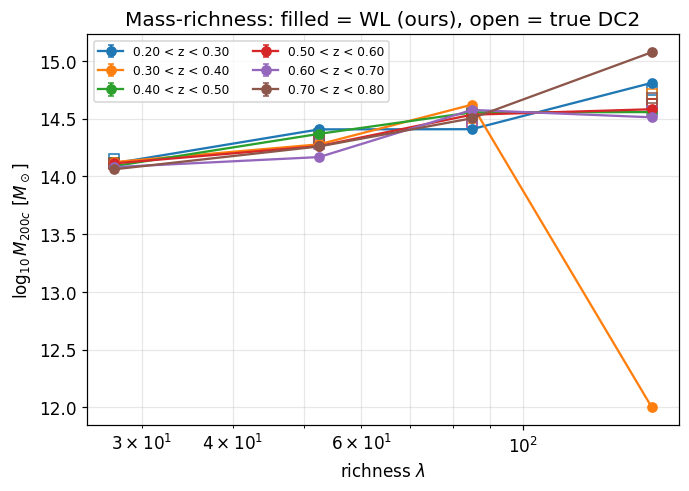

In [10]:
if have_truth:
    fig, ax = plt.subplots(figsize=(6.4, 4.6))
    for zk in zkeys:
        grp = sorted([b for b in zgroups[zk] if b["r_mid"] is not None],
                     key=lambda b: b["r_mid"])
        if not grp:
            continue
        c = zcolor[zk]
        ax.errorbar([b["r_mid"] for b in grp], [b["logm"] for b in grp],
                    yerr=[b["logm_err"] for b in grp], fmt="o-", color=c,
                    capsize=2, label=zlabel(zk))
        tt = [b for b in grp if np.isfinite(b.get("logm_true", np.nan))]
        if tt:
            ax.plot([b["r_mid"] for b in tt], [b["logm_true"] for b in tt],
                    "s", mfc="none", color=c)
    ax.set_xscale("log")
    ax.set_xlabel(r"richness $\lambda$")
    ax.set_ylabel(r"$\log_{10} M_{200c}\ [M_\odot]$")
    ax.set_title("Mass-richness: filled = WL (ours), open = true DC2")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
else:
    print("Skipped (needs the matched-pairs truth).")

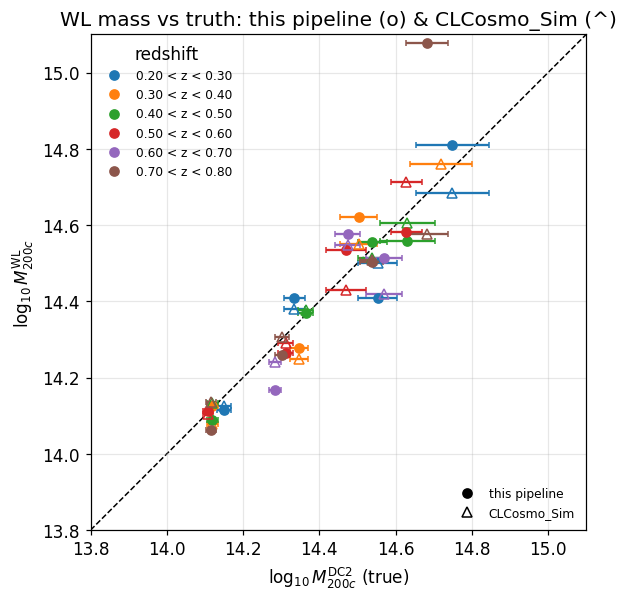

In [13]:
# --- All three together (A): both WL estimates vs true DC2 mass, on y=x ---
import matplotlib.lines as mlines
if not have_truth:
    print("Need the matched-pairs truth for this panel.")
else:
    have_clc = clc is not None
    if have_clc:  # attach CLCosmo_Sim mass to each bin by (z, lambda)-box match
        zc = np.array(clc[CLC_Z], float); rc = np.array(clc[CLC_OBS], float)
        mc = np.array(clc[CLC_LOGM], float); mce = np.array(clc[CLC_LOGM_ERR], float)
        for b in bins:
            b["logm_clc"], b["logm_clc_err"] = np.nan, np.nan
            if None in (b["z_lo"], b["z_hi"], b["r_lo"], b["r_hi"]):
                continue
            sel = (zc > b["z_lo"]) & (zc < b["z_hi"]) & (rc > b["r_lo"]) & (rc < b["r_hi"])
            if sel.sum():
                b["logm_clc"] = float(np.mean(mc[sel]))
                b["logm_clc_err"] = float(np.mean(mce[sel]))

    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.plot(LIMS, LIMS, "--k", zorder=0, lw=1)
    for zk in zkeys:
        c = zcolor[zk]
        grp = [b for b in zgroups[zk] if np.isfinite(b.get("logm_true", np.nan))]
        if not grp:
            continue
        ax.errorbar([b["logm_true"] for b in grp], [b["logm"] for b in grp],
                    xerr=[b["logm_true_err"] for b in grp], yerr=[b["logm_err"] for b in grp],
                    fmt="o", color=c, capsize=2)
        if have_clc:
            gc = [b for b in grp if np.isfinite(b.get("logm_clc", np.nan))]
            if gc:
                ax.errorbar([b["logm_true"] for b in gc], [b["logm_clc"] for b in gc],
                            xerr=[b["logm_true_err"] for b in gc],
                            fmt="^", color=c, mfc="none", capsize=2)
    ax.set_xlim(LIMS); ax.set_ylim(LIMS); ax.set_box_aspect(1)
    ax.set_xlabel(r"$\log_{10} M_{200c}^{\rm DC2}$ (true)")
    ax.set_ylabel(r"$\log_{10} M_{200c}^{\rm WL}$")
    ax.set_title("WL mass vs truth: this pipeline (o) & CLCosmo_Sim (^)")
    z_handles = [mlines.Line2D([], [], color=zcolor[zk], marker="o", ls="", label=zlabel(zk)) for zk in zkeys]
    src = [mlines.Line2D([], [], color="k", marker="o", ls="", label="this pipeline")]
    if have_clc:
        src.append(mlines.Line2D([], [], color="k", marker="^", mfc="none", ls="", label="CLCosmo_Sim"))
    leg1 = ax.legend(handles=z_handles, fontsize=8, loc="upper left", frameon=False, title="redshift")
    ax.add_artist(leg1)
    ax.legend(handles=src, fontsize=8, loc="lower right", frameon=False)
    ax.grid(True, alpha=0.3); fig.tight_layout()

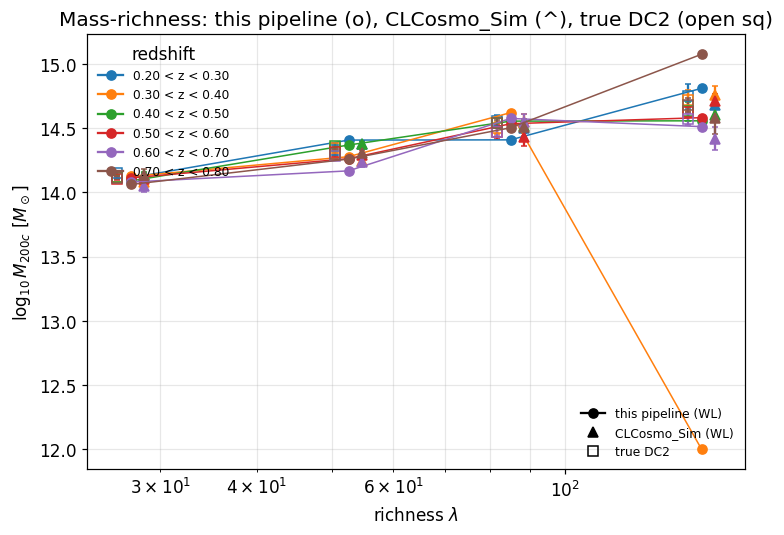

In [12]:
# --- All three together (B): mass-richness, ours + CLCosmo_Sim + true DC2 ---
import matplotlib.lines as mlines
have_clc = clc is not None
if have_clc:
    zc = np.array(clc[CLC_Z], float); rc = np.array(clc[CLC_OBS], float)
    mc = np.array(clc[CLC_LOGM], float); mce = np.array(clc[CLC_LOGM_ERR], float)
    for b in bins:
        b["logm_clc"], b["logm_clc_err"] = np.nan, np.nan
        if None in (b["z_lo"], b["z_hi"], b["r_lo"], b["r_hi"]):
            continue
        sel = (zc > b["z_lo"]) & (zc < b["z_hi"]) & (rc > b["r_lo"]) & (rc < b["r_hi"])
        if sel.sum():
            b["logm_clc"] = float(np.mean(mc[sel])); b["logm_clc_err"] = float(np.mean(mce[sel]))

OFF = {"ours": 1.0, "clc": 1.04, "true": 0.96}   # tiny x-offsets so points don't overlap
fig, ax = plt.subplots(figsize=(7.0, 5.0))
for zk in zkeys:
    c = zcolor[zk]
    grp = sorted([b for b in zgroups[zk] if b["r_mid"] is not None], key=lambda b: b["r_mid"])
    if not grp:
        continue
    r = np.array([b["r_mid"] for b in grp], float)
    ax.errorbar(r * OFF["ours"], [b["logm"] for b in grp], yerr=[b["logm_err"] for b in grp],
                fmt="o-", color=c, capsize=2, lw=1)
    if have_clc:
        sub = [b for b in grp if np.isfinite(b.get("logm_clc", np.nan))]
        if sub:
            ax.errorbar([b["r_mid"] * OFF["clc"] for b in sub], [b["logm_clc"] for b in sub],
                        yerr=[b["logm_clc_err"] for b in sub], fmt="^", color=c, capsize=2, ls="")
    if have_truth:
        sub = [b for b in grp if np.isfinite(b.get("logm_true", np.nan))]
        if sub:
            ax.errorbar([b["r_mid"] * OFF["true"] for b in sub], [b["logm_true"] for b in sub],
                        yerr=[b["logm_true_err"] for b in sub], fmt="s", mfc="none", color=c,
                        capsize=2, ls="")
ax.set_xscale("log")
ax.set_xlabel(r"richness $\lambda$"); ax.set_ylabel(r"$\log_{10} M_{200c}\ [M_\odot]$")
ax.set_title("Mass-richness: this pipeline (o), CLCosmo_Sim (^), true DC2 (open sq)")
ax.grid(True, which="both", alpha=0.3)
z_handles = [mlines.Line2D([], [], color=zcolor[zk], marker="o", ls="-", label=zlabel(zk)) for zk in zkeys]
src = [mlines.Line2D([], [], color="k", marker="o", ls="-", label="this pipeline (WL)")]
if have_clc:
    src.append(mlines.Line2D([], [], color="k", marker="^", ls="", label="CLCosmo_Sim (WL)"))
if have_truth:
    src.append(mlines.Line2D([], [], color="k", marker="s", mfc="none", ls="", label="true DC2"))
leg1 = ax.legend(handles=z_handles, fontsize=8, loc="upper left", title="redshift", frameon=False)
ax.add_artist(leg1)
ax.legend(handles=src, fontsize=8, loc="lower right", frameon=False)
fig.tight_layout()